In [1]:
# Libraries and configurations
import sys
from pathlib import Path
import json

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from torchvision import transforms
from torchinfo import summary

# Visualization and analysis
import os
import seaborn as sns
import PIL
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import cohen_kappa_score

# Adds the project root to the path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

from config import (
    get_dataset_paths
)

from src.dataset import DataModuleParasite

seed = 42
torch.manual_seed(seed)
np.random.seed(seed)

### Configurações Gerais

In [2]:
# Functions for training and evaluation

class AverageMeter:
    def __init__(self):
        self.reset()

    def reset(self):
        self.val = 0
        self.avg = 0
        self.sum = 0
        self.count = 0

    def update(self, val, n=1):
        self.val = val
        self.sum += val * n
        self.count += n
        self.avg = self.sum / self.count

def train(model, train_loader, criterion, optimizer, device):
    model.train()
    
    train_loss_avg = AverageMeter()
    train_acc_avg = AverageMeter()

    for input, label in tqdm(train_loader, desc="Training", leave=False):
        input, label = input.to(device), label.to(device)

        # Forward
        optimizer.zero_grad()
        outputs = model(input)
        loss = criterion(outputs, label)

        # Backward
        loss.backward()
        optimizer.step()
        
        # Predictions 
        _, preds = torch.max(outputs, 1)
        
        # Metrics for batch
        batch_acc = (preds == label).sum().item() / label.size(0)

        train_loss_avg.update(loss.item(), label.size(0))
        train_acc_avg.update(batch_acc, label.size(0))

    return train_loss_avg.avg, train_acc_avg.avg

def evaluate(model, val_loader, criterion, device):
    model.eval()
    
    val_loss_avg = AverageMeter()
    val_acc_avg = AverageMeter()
    
    with torch.no_grad():
        for input, label in tqdm(val_loader, desc="Validation", leave=False):
            input, label = input.to(device), label.to(device)

            # Forward
            outputs = model(input)
            loss = criterion(outputs, label)

            # Predictions
            _, preds = torch.max(outputs, 1)

            # Metrics for batch
            batch_acc = (preds == label).sum().item() / label.size(0)

            val_loss_avg.update(loss.item(), label.size(0))
            val_acc_avg.update(batch_acc, label.size(0))

    return val_loss_avg.avg, val_acc_avg.avg

def create_efficientnetv2_model(description_path=None, config=None):
    # create model instance
    model = models.efficientnet_v2_s(weights=models.EfficientNet_V2_S_Weights.IMAGENET1K_V1)
    model.classifier[1] = nn.Linear(in_features=1280, out_features=config['num_classes'])
    model = model.to(config['device'])
    
    # count parameters
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    # save model description
    if description_path:
        os.makedirs(os.path.dirname(description_path), exist_ok=True)
        with open(description_path, "w") as f:
            f.write(f"Total parameters: {total_params}\n")
            f.write(f"Trainable parameters: {trainable_params}\n")
            f.write(f"Model Architecture:\n{model}\n")
    
    # Loss , Optimizer and Scheduler
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=config['lr'])
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)
    
    return model, criterion, optimizer, scheduler

def generate_mean_std_report(results_data, percentage, split_list):
    reports_list = []
    kappa_list = [] 

    # 1. Collect the data (Reports and Kappas)
    for split in split_list:
        data_split = results_data[percentage][split]
        if 'classification_report_dict' in data_split:
            reports_list.append(data_split['classification_report_dict'])
            kappa_list.append(data_split['kappa'])
        else:
            return None

    # 2. Prepare the DataFrame
    keys = list(reports_list[0].keys())
    # Remove 'accuracy' from keys if it appears as a standalone key (handled separately)
    if 'accuracy' in keys: keys.remove('accuracy')
    
    final_df = pd.DataFrame(index=keys + ['accuracy', 'Cohen Kappa'], 
                            columns=['precision', 'recall', 'f1-score', 'support'])

    # 3. Fill Classes and Averages (Macro/Weighted)
    for key in keys:
        for metric in ['precision', 'recall', 'f1-score', 'support']:
            values = [r[key][metric] for r in reports_list]
            mean_val, std_val = np.mean(values), np.std(values)
            
            if metric == 'support':
                final_df.loc[key, metric] = f"{int(mean_val)}"
            else:
                final_df.loc[key, metric] = f"{mean_val:.4f} ± {std_val:.4f}"

    # 4. Fill Accuracy
    acc_values = [r['accuracy'] for r in reports_list]
    final_df.loc['accuracy', 'f1-score'] = f"{np.mean(acc_values):.4f} ± {np.std(acc_values):.4f}"
    # Optional: put total support in the accuracy row
    total_support = int(np.mean([r['macro avg']['support'] for r in reports_list]))
    final_df.loc['accuracy', 'support'] = f"{total_support}"

    # 5. Fill Cohen Kappa (NEW)
    # Kappa doesn't have precision/recall, so we put the result in the f1-score column (or create a new one)
    k_mean = np.mean(kappa_list)
    k_std = np.std(kappa_list)
    final_df.loc['Cohen Kappa', 'f1-score'] = f"{k_mean:.4f} ± {k_std:.4f}"

    # Replace NaN with empty string for cleaner visual appearance
    return final_df.fillna('')

In [3]:
# calcular o número de flops do modelo
def count_flops(model, input_size=(1, 3, 200, 200)):
    from thop import profile
    dummy_input = torch.randn(input_size).to(next(model.parameters()).device)
    flops, params = profile(model, inputs=(dummy_input,), verbose=False)
    return flops, params

### Eggs

In [4]:
# Configuration for Larvae Dataset

CONFIG_EGG = {
    'dataset_name': 'eggs',
    'split': [1, 2, 3],
    'percentage': [1, 5, 25, 50, 75, 100],
    'num_classes': 9,
    'batch_size': 16,
    'num_workers': 4,
    'image_size': 200,
    'lr': 1e-4,
    'num_epochs': 100,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu'
}

# Create dataloaders
dataloaders_egg = {}

transforms_egg = transforms.Compose([
    transforms.Resize((CONFIG_EGG['image_size'], CONFIG_EGG['image_size'])),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

for split in CONFIG_EGG['split']:
    dataloaders_egg[split] = {}
    for perc in CONFIG_EGG['percentage']:
        data_module = DataModuleParasite(
            dataset_name=CONFIG_EGG['dataset_name'],
            split=split,
            percentage=perc,
            batch_size=CONFIG_EGG['batch_size'],
            num_workers=CONFIG_EGG['num_workers'],
            transform=transforms_egg
        )
        data_module.setup()
        dataloaders_egg[split][perc] = {
            'train': data_module.train_dataloader(),
            'val': data_module.val_dataloader(),
            'test': data_module.test_dataloader()
        }

model_pretrained, _, _, _ = create_efficientnetv2_model(description_path="efficientnetv2/eggs/efficientnetv2_model_params_eggs.txt", config=CONFIG_EGG)


In [5]:
n_flops, n_params = count_flops(model_pretrained, input_size=(1, 3, CONFIG_EGG['image_size'], CONFIG_EGG['image_size']))
print(f"Model: efficientnetv2 - Dataset: {CONFIG_EGG['dataset_name']}")
# mostra o valor total
print(f"FLOPs: {n_flops} FLOPs")
print(f"Parameters: {n_params} ")

Model: efficientnetv2 - Dataset: eggs
FLOPs: 2480073792.0 FLOPs
Parameters: 20189017.0 


In [5]:
historic_eggs = {}
patience = 20 

for perc in CONFIG_EGG['percentage']:
    historic_eggs[perc] = {}
    for split in CONFIG_EGG['split']:

        model_pretrained, criterion, optimizer, scheduler = create_efficientnetv2_model(None, CONFIG_EGG)

        epochs_no_improve = 0
        
        best_val_acc = 0.0
        historic_eggs[perc][split] = {
            'train_loss': [],
            'train_acc': [],
            'val_loss': [],
            'val_acc': []
        }
        
        for epoch in tqdm(range(CONFIG_EGG['num_epochs']), desc=f"Split {split} - Percentage {perc}%", leave=False):
            
            val_loss, val_acc = evaluate(model_pretrained, dataloaders_egg[split][perc]['val'], criterion, CONFIG_EGG['device'])

            train_loss, train_acc = train(model_pretrained, dataloaders_egg[split][perc]['train'], criterion, optimizer, CONFIG_EGG['device'])

            historic_eggs[perc][split]['train_loss'].append(train_loss)
            historic_eggs[perc][split]['train_acc'].append(train_acc)
            historic_eggs[perc][split]['val_loss'].append(val_loss)
            historic_eggs[perc][split]['val_acc'].append(val_acc)
            
            # Early Stopping
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                epochs_no_improve = 0
                os.makedirs('efficientnetv2/eggs/best_models_eggs', exist_ok=True)
                torch.save(model_pretrained.state_dict(), f'efficientnetv2/eggs/best_models_eggs/efficientnetv2_best_split{split}_perc{perc}.pth')
            else:
                epochs_no_improve += 1
                if epochs_no_improve >= patience:
                    print(f'Early stopping at epoch {epoch+1} for split {split} and percentage {perc}%')
                    break

        val_loss, val_acc = evaluate(model_pretrained, dataloaders_egg[split][perc]['val'], criterion, CONFIG_EGG['device'])

        historic_eggs[perc][split]['val_loss'].append(val_loss)
        historic_eggs[perc][split]['val_acc'].append(val_acc)
            
        scheduler.step()
        
# Save training history
with open('efficientnetv2/eggs/efficientnetv2_historic_eggs.json', 'w') as f:
    json.dump(historic_eggs, f)

Early stopping at epoch 68 for split 1 and percentage 1%


Early stopping at epoch 22 for split 2 and percentage 1%


Early stopping at epoch 77 for split 1 and percentage 5%


Early stopping at epoch 49 for split 2 and percentage 5%


Early stopping at epoch 67 for split 3 and percentage 5%


...

Early stopping at epoch 38 for split 2 and percentage 75%


Early stopping at epoch 40 for split 3 and percentage 75%


Early stopping at epoch 33 for split 1 and percentage 100%


Early stopping at epoch 30 for split 2 and percentage 100%


Early stopping at epoch 29 for split 3 and percentage 100%


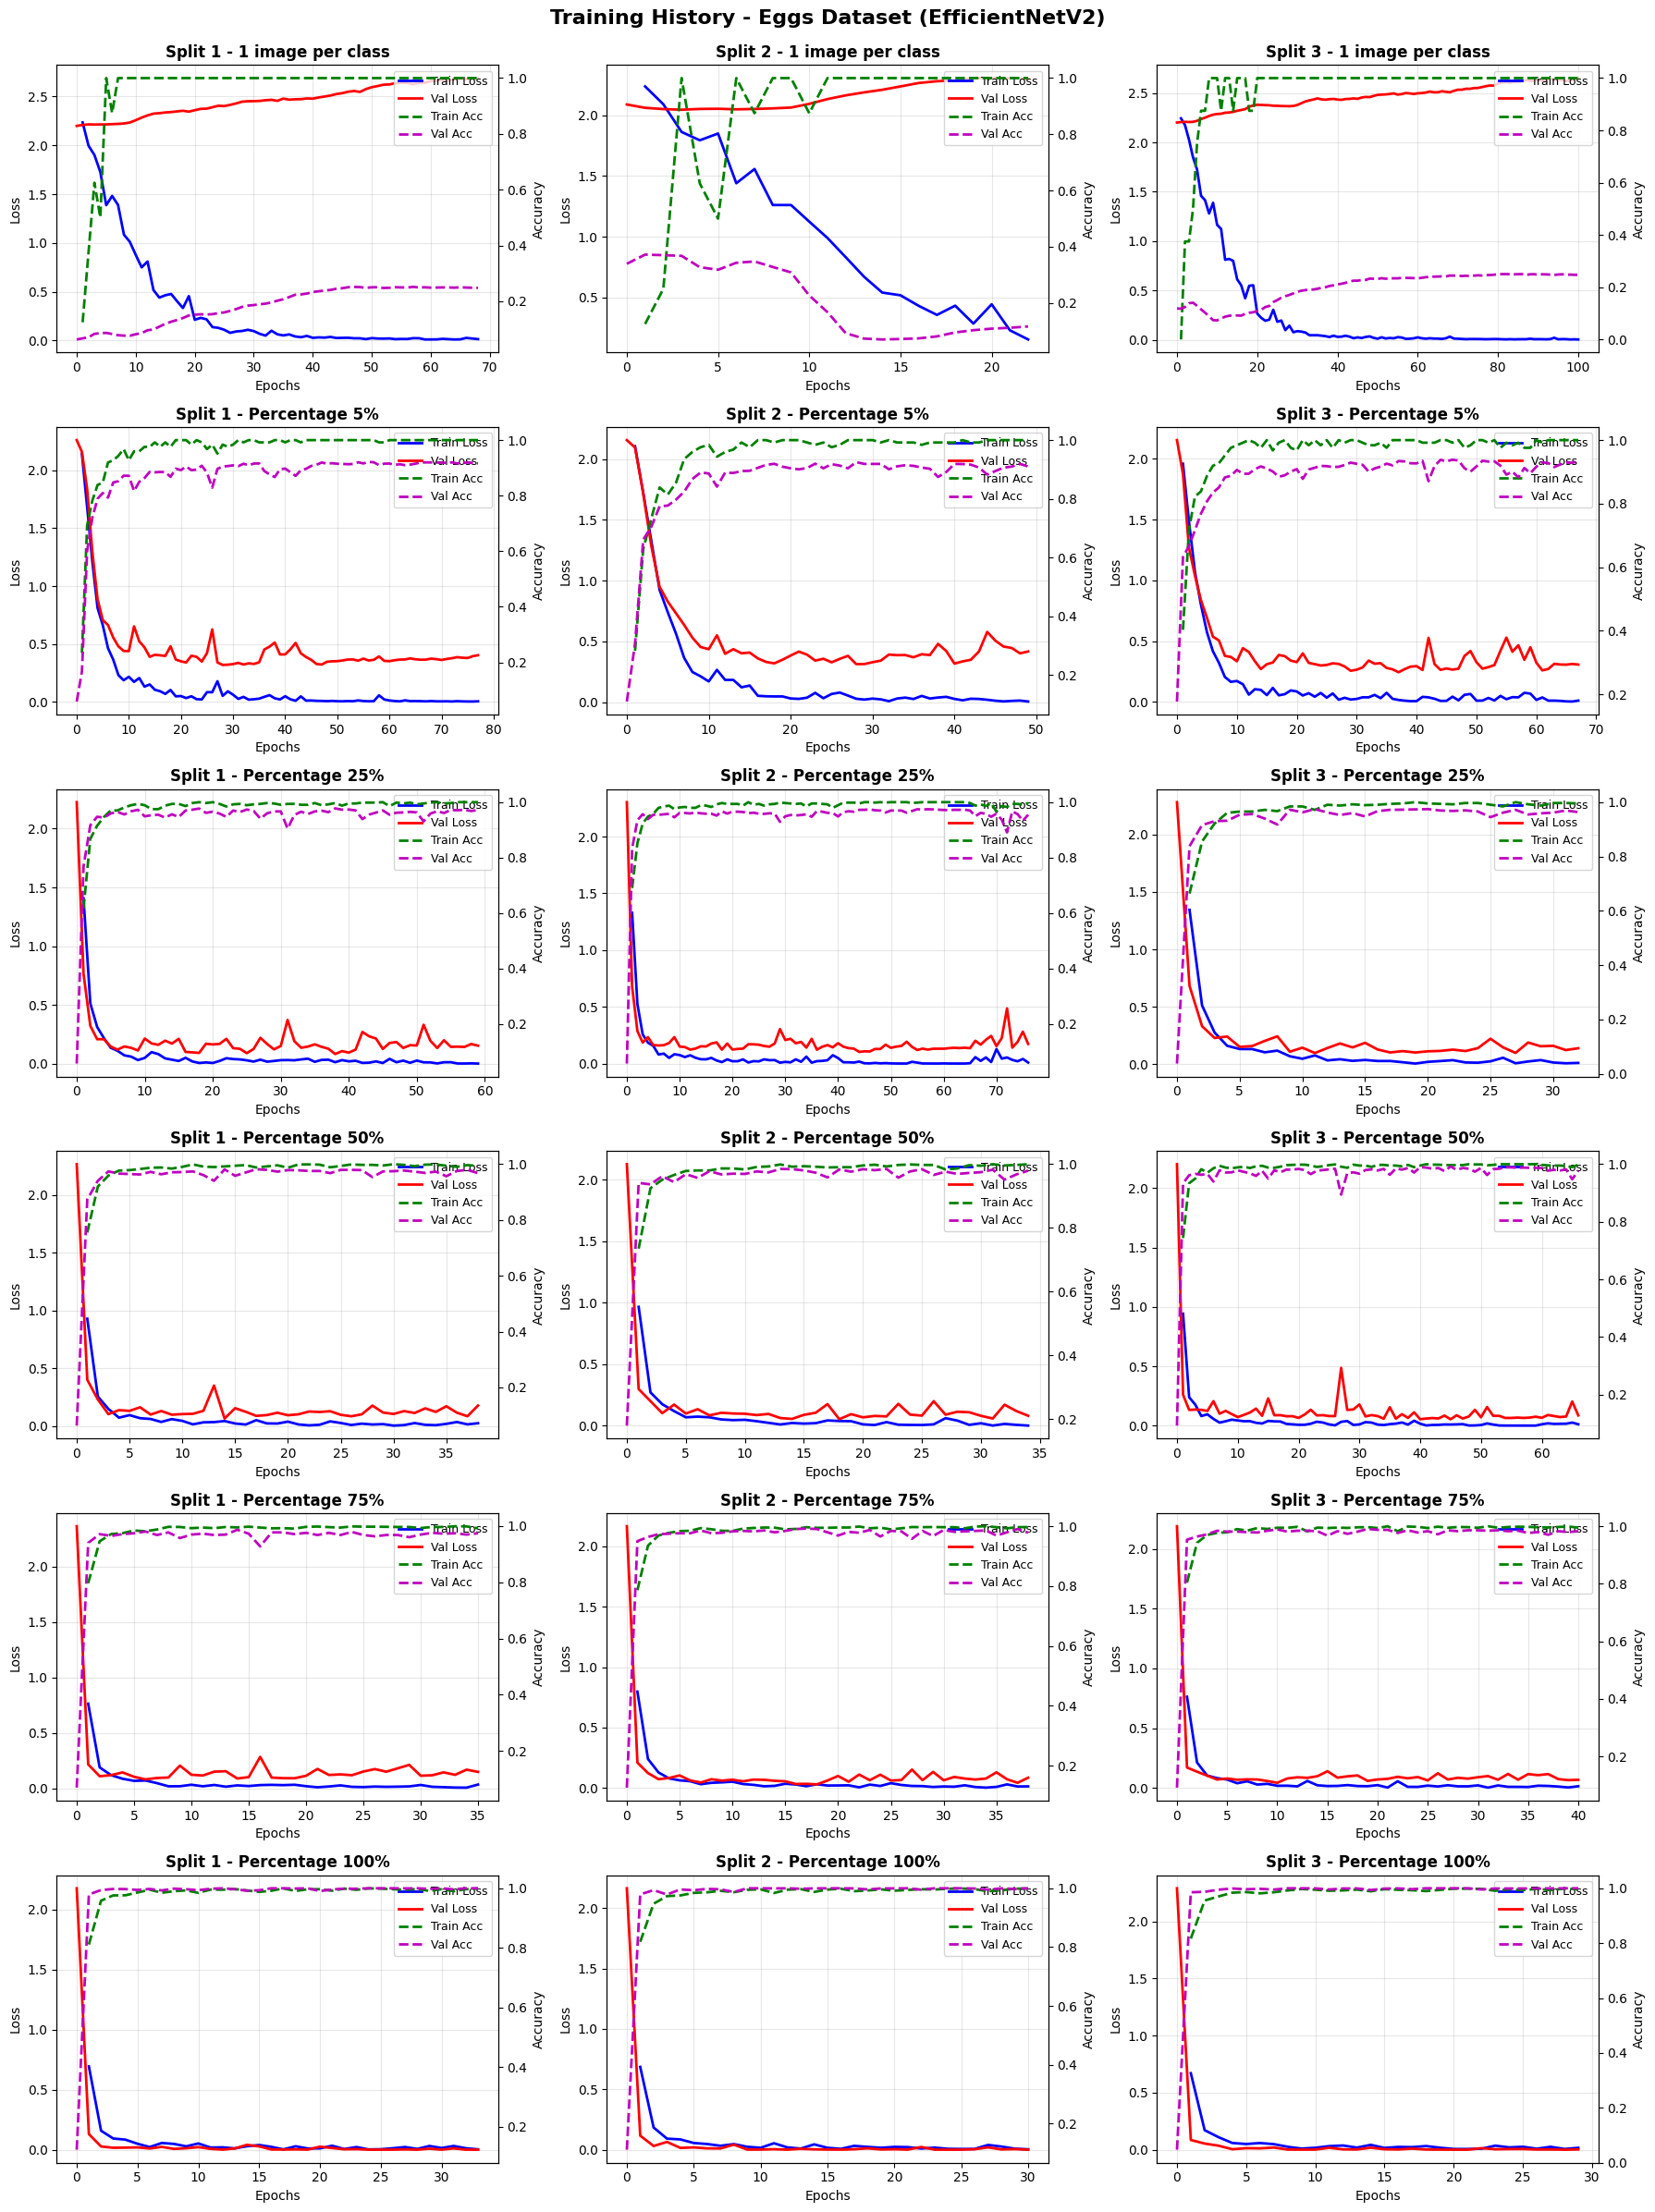

In [5]:
load = False
# load historic from json - commented out because already loaded above 
load = True
with open('efficientnetv2/eggs/efficientnetv2_historic_eggs.json', 'r') as f:
    historic_eggs = json.load(f)

# Loss and Accuracy plots for eggs dataset (EfficientNetV2)
fig, axes = plt.subplots(len(CONFIG_EGG['percentage']), len(CONFIG_EGG['split']), 
                         figsize=(18, 4 * len(CONFIG_EGG['percentage'])))

for perc_idx, perc in enumerate(CONFIG_EGG['percentage']):
    for split_idx, split in enumerate(CONFIG_EGG['split']):
        ax = axes[perc_idx, split_idx]
        
        if load==True:
            history = historic_eggs[str(perc)][str(split)]
        else:
            history = historic_eggs[perc][split]
        epochs = range(1, len(history['train_loss']) + 1)
        epochs_val = range(0, len(history['val_loss']))
        
        # Plot loss
        ax_loss = ax
        ax_loss.plot(epochs, history['train_loss'], 'b-', label='Train Loss', linewidth=2)
        ax_loss.plot(epochs_val, history['val_loss'], 'r-', label='Val Loss', linewidth=2)
        ax_loss.set_xlabel('Epochs')
        ax_loss.set_ylabel('Loss', color='black')
        ax_loss.tick_params(axis='y', labelcolor='black')
        
        # Create secondary y-axis for accuracy
        ax_acc = ax.twinx()
        ax_acc.plot(epochs, history['train_acc'], 'g--', label='Train Acc', linewidth=2)
        ax_acc.plot(epochs_val, history['val_acc'], 'm--', label='Val Acc', linewidth=2)
        ax_acc.set_ylabel('Accuracy', color='black')
        ax_acc.tick_params(axis='y', labelcolor='black')
        
        # Title
        if perc == 1:
            ax.set_title(f'Split {split} - 1 image per class', fontsize=12, fontweight='bold')
        else: 
            ax.set_title(f'Split {split} - Percentage {perc}%', fontsize=12, fontweight='bold')
        
        # Grid
        ax.grid(True, alpha=0.3)
        
        # Combine legends
        lines1, labels1 = ax_loss.get_legend_handles_labels()
        lines2, labels2 = ax_acc.get_legend_handles_labels()
        ax.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=9)

plt.suptitle('Training History - Eggs Dataset (EfficientNetV2)', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('efficientnetv2/eggs/training_history_eggs_grid_efficientnetv2.png', dpi=300, bbox_inches='tight')
plt.show()

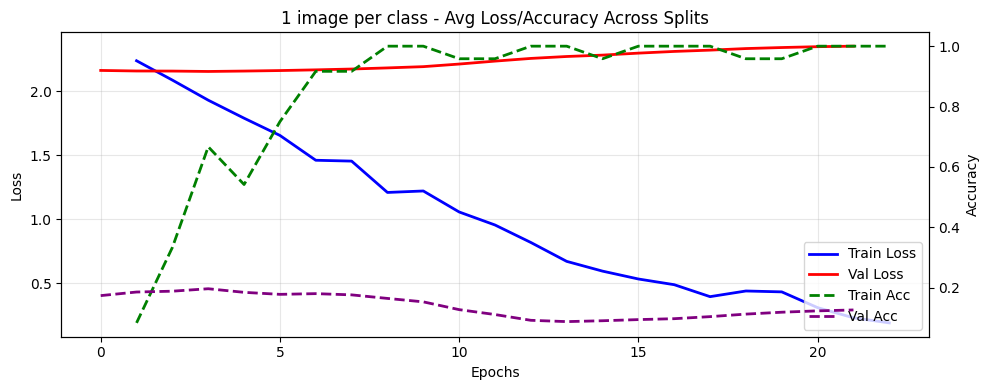

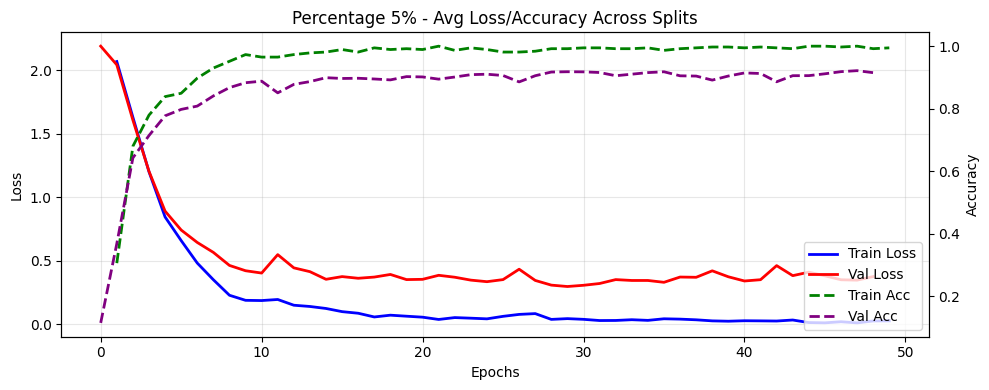

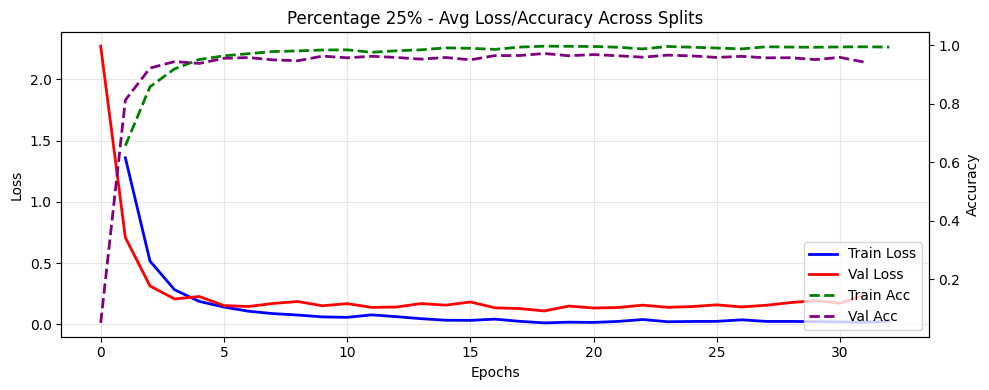

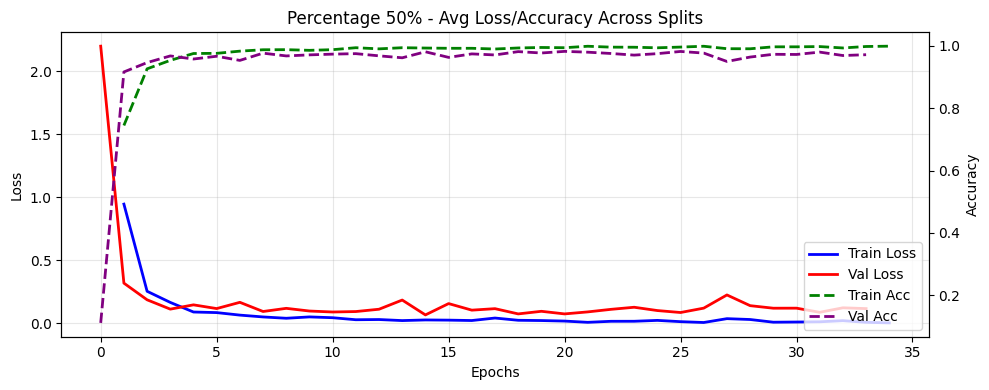

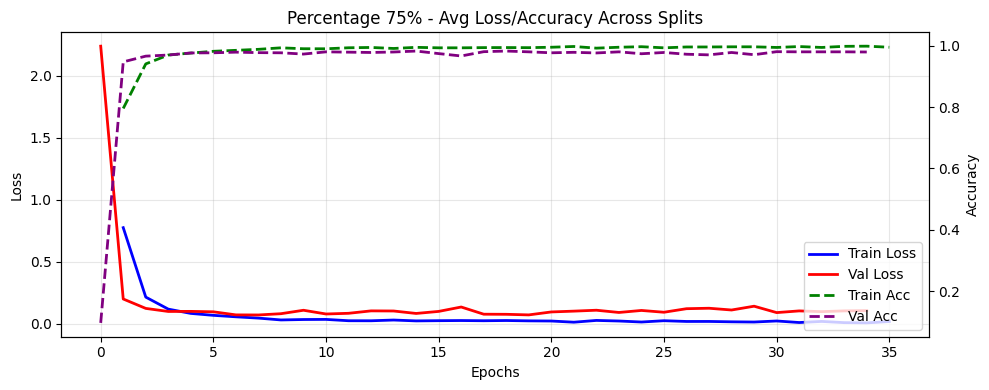

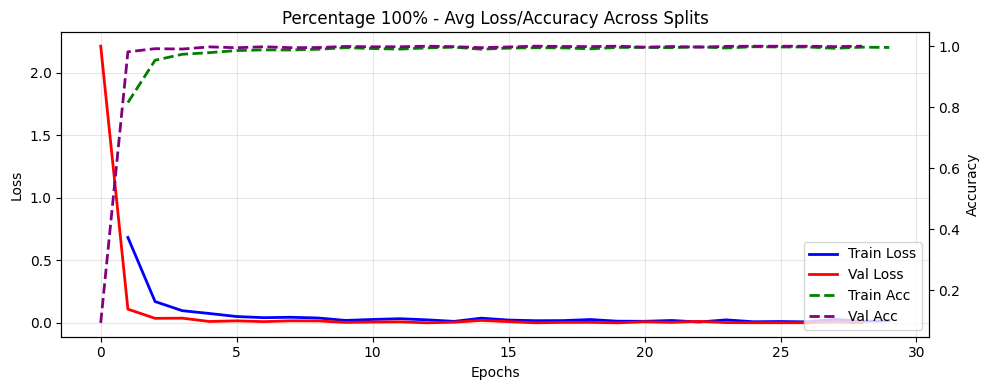

In [6]:
load = False
# load historic from json - commented out because already loaded above
load = True
with open('efficientnetv2/eggs/efficientnetv2_historic_eggs.json', 'r') as f:
    historic_eggs = json.load(f)

# Loss and Accuracy aggregated plots for eggs dataset (EfficientNetV2)
agg_rows = []
for perc in CONFIG_EGG['percentage']:
    all_train_loss = []
    all_val_loss = []
    all_train_acc = []
    all_val_acc = []
    
    # Collect histories for all splits
    for split in CONFIG_EGG['split']:
        if load==True:
            history = historic_eggs[str(perc)][str(split)]
        else:
            history = historic_eggs[perc][split]
        all_train_loss.append(history['train_loss'])
        all_val_loss.append(history['val_loss'])
        all_train_acc.append(history['train_acc'])
        all_val_acc.append(history['val_acc'])
    
    # Find the minimum number of epochs across splits (due to early stopping)
    min_len = min(len(x) for x in all_train_loss)
    
    # Truncate all histories to the minimum length
    all_train_loss_trunc = [x[:min_len] for x in all_train_loss]
    all_val_loss_trunc = [x[:min_len] for x in all_val_loss]
    all_train_acc_trunc = [x[:min_len] for x in all_train_acc]
    all_val_acc_trunc = [x[:min_len] for x in all_val_acc]
    
    # Calculate averages
    avg_train_loss = np.mean(all_train_loss_trunc, axis=0)
    avg_val_loss = np.mean(all_val_loss_trunc, axis=0)
    avg_train_acc = np.mean(all_train_acc_trunc, axis=0)
    avg_val_acc = np.mean(all_val_acc_trunc, axis=0)
    
    # Store aggregated results
    agg_rows.append({
        'percentage': perc,
        'avg_train_loss': avg_train_loss,
        'avg_val_loss': avg_val_loss,
        'avg_train_acc': avg_train_acc,
        'avg_val_acc': avg_val_acc,
    })

# Plot aggregated loss and accuracy per percentage
for agg in agg_rows:
    epochs = range(1, len(agg['avg_train_loss']) + 1)
    epochs_val = range(0, len(agg['avg_val_loss']))
    
    fig, ax1 = plt.subplots(figsize=(10, 4))
    ax1.plot(epochs, agg['avg_train_loss'], label='Train Loss', color='blue', linewidth=2)
    ax1.plot(epochs_val, agg['avg_val_loss'], label='Val Loss', color='red', linewidth=2)
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.grid(True, alpha=0.3)

    ax2 = ax1.twinx()
    ax2.plot(epochs, agg['avg_train_acc'], label='Train Acc', color='green', linestyle='--', linewidth=2)
    ax2.plot(epochs_val, agg['avg_val_acc'], label='Val Acc', color='purple', linestyle='--', linewidth=2)
    ax2.set_ylabel('Accuracy')

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower right')

    if agg['percentage'] == 1:
        ax1.set_title(f'1 image per class - Avg Loss/Accuracy Across Splits')
    else:   
        ax1.set_title(f'Percentage {agg["percentage"]}% - Avg Loss/Accuracy Across Splits')
    plt.savefig(f'efficientnetv2/eggs/aggregated_loss_accuracy_eggs_perc{agg["percentage"]}.png', dpi=300, bbox_inches='tight')
    
    plt.tight_layout()
    plt.show()


In [7]:
# Evaluate on test set and save metrics
results_eggs = {}

for perc in CONFIG_EGG['percentage']:
    results_eggs[perc] = {}
    for split in CONFIG_EGG['split']:
        
        # Create a model instance that matches the checkpoint (uses CONFIG_EGG)
        efficientnetv2_model_eval, _, _, _ = create_efficientnetv2_model(None, CONFIG_EGG)
        # Load the checkpoint into that model (ensure loading on correct device)
        efficientnetv2_model_eval.load_state_dict(torch.load(
            f'efficientnetv2/eggs/best_models_eggs/efficientnetv2_best_split{split}_perc{perc}.pth',
            map_location=CONFIG_EGG['device']
        ))
        efficientnetv2_model_eval.to(CONFIG_EGG['device'])
        efficientnetv2_model_eval.eval()
        
        all_preds = []
        all_labels = []
        
        with torch.no_grad():
            for inputs, labels in tqdm(dataloaders_egg[split][perc]['test'], desc=f'Testing Split {split} Perc {perc}%', leave=False):
                inputs, labels = inputs.to(CONFIG_EGG['device']), labels.to(CONFIG_EGG['device'])
                outputs = efficientnetv2_model_eval(inputs)
                _, preds = torch.max(outputs, 1)
                
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
        
        # Calculate metrics
        cm = confusion_matrix(all_labels, all_preds)
        kappa = cohen_kappa_score(all_labels, all_preds)
        report_dic = classification_report(all_labels, all_preds, zero_division=0, output_dict=True)
        report_str = classification_report(all_labels, all_preds, zero_division=0) 
        
        # Store results
        results_eggs[perc][split] = {
            'confusion_matrix': cm.tolist(),
            'kappa': float(kappa),
            'classification_report_dict': report_dic,
            'classification_report_str': report_str
        }
        
# Save results to JSON
with open('efficientnetv2/eggs/efficientnetv2_test_results_eggs.json', 'w') as f:
    json.dump(results_eggs, f)

In [8]:
load = False
# Load results from JSON - commented out because already loaded above
load = True
with open('efficientnetv2/eggs/efficientnetv2_test_results_eggs.json', 'r') as f:
    results_eggs = json.load(f)

# JSON keys become strings after loading. Convert keys back to ints when possible
def _convert_keys_to_int(obj):
    if isinstance(obj, dict):
        new = {}
        for k, v in obj.items():
            try:
                new_k = int(k)
            except Exception:
                new_k = k
            new[new_k] = _convert_keys_to_int(v)
        return new
    return obj

results_eggs = _convert_keys_to_int(results_eggs)

# delete any existing aggregated report file
if os.path.exists('efficientnetv2/eggs/efficientnetv2_aggregated_classification_report_eggs.txt'):
    os.remove('efficientnetv2/eggs/efficientnetv2_aggregated_classification_report_eggs.txt')

print("=== Aggregated Reports (Mean ± Standard Deviation) ===")

for perc in CONFIG_EGG['percentage']:
    # print(f"\n>> Percentage: {perc}%")
    df_result = generate_mean_std_report(results_eggs, perc, CONFIG_EGG['split'])
    
    if df_result is not None:
        # Cosmetic adjustment to match sklearn print
        # Replace NaN with empty string to clean the accuracy line
        # print(df_result.fillna('').to_markdown()) 
        
        # Optional: Save all percentages in a single txt        
        with open('efficientnetv2/eggs/efficientnetv2_aggregated_classification_report_eggs.txt', 'a') as f:
            f.write(f"\n>> Percentage: {perc}%\n")
            f.write(df_result.fillna('').to_string())
            f.write("\n\n")

=== Aggregated Reports (Mean ± Standard Deviation) ===


### Cistos

In [6]:
# Configuration for Cisto Dataset
CONFIG_CISTO = {
    'dataset_name': 'cistos',
    'split': [1, 2, 3],
    'percentage': [1, 5, 25, 50, 75, 100],
    'num_classes': 7,
    'batch_size': 16,
    'num_workers': 4,
    'image_size': 200,
    'lr': 1e-4,
    'num_epochs': 100,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu'
}


# Create dataloaders
dataloaders_cisto = {}

transforms_cisto = transforms.Compose([
    transforms.Resize((CONFIG_CISTO['image_size'], CONFIG_CISTO['image_size'])),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

for split in CONFIG_CISTO['split']:
    dataloaders_cisto[split] = {}
    for perc in CONFIG_CISTO['percentage']:
        data_module = DataModuleParasite(
            dataset_name=CONFIG_CISTO['dataset_name'],
            split=split,
            percentage=perc,
            batch_size=CONFIG_CISTO['batch_size'],
            num_workers=CONFIG_CISTO['num_workers'],
            transform=transforms_cisto
        )
        data_module.setup()
        dataloaders_cisto[split][perc] = {
            'train': data_module.train_dataloader(),
            'val': data_module.val_dataloader(),
            'test': data_module.test_dataloader()
        }

model_pretrained, _, _, _ = create_efficientnetv2_model(description_path="efficientnetv2/cistos/efficientnetv2_model_params_cistos.txt", config=CONFIG_CISTO)

In [7]:
n_flops, n_params = count_flops(model_pretrained, input_size=(1, 3, CONFIG_CISTO['image_size'], CONFIG_CISTO['image_size']))
print(f"Model: efficientnetv2 - Dataset: {CONFIG_CISTO['dataset_name']}")
# mostra o valor total
print(f"FLOPs: {n_flops} FLOPs")
print(f"Parameters: {n_params} ")

Model: efficientnetv2 - Dataset: cistos
FLOPs: 2480071232.0 FLOPs
Parameters: 20186455.0 


In [9]:
historic_cistos = {}
patience = 20 

for perc in CONFIG_CISTO['percentage']:
    historic_cistos[perc] = {}
    for split in CONFIG_CISTO['split']:

        model_pretrained, criterion, optimizer, scheduler = create_efficientnetv2_model(None, CONFIG_CISTO)

        epochs_no_improve = 0
        
        best_val_acc = 0.0
        historic_cistos[perc][split] = {
            'train_loss': [],
            'train_acc': [],
            'val_loss': [],
            'val_acc': []
        }
        
        for epoch in tqdm(range(CONFIG_CISTO['num_epochs']), desc=f"Split {split} - Percentage {perc}%", leave=False):
            
            val_loss, val_acc = evaluate(model_pretrained, dataloaders_cisto[split][perc]['val'], criterion, CONFIG_CISTO['device'])

            train_loss, train_acc = train(model_pretrained, dataloaders_cisto[split][perc]['train'], criterion, optimizer, CONFIG_CISTO['device'])

            historic_cistos[perc][split]['train_loss'].append(train_loss)
            historic_cistos[perc][split]['train_acc'].append(train_acc)
            historic_cistos[perc][split]['val_loss'].append(val_loss)
            historic_cistos[perc][split]['val_acc'].append(val_acc)
            
            # Early Stopping
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                epochs_no_improve = 0
                os.makedirs('efficientnetv2/cistos/best_models_cistos', exist_ok=True)
                torch.save(model_pretrained.state_dict(), f'efficientnetv2/cistos/best_models_cistos/efficientnetv2_best_split{split}_perc{perc}.pth')
            else:
                epochs_no_improve += 1
                if epochs_no_improve >= patience:
                    print(f'Early stopping at epoch {epoch+1} for split {split} and percentage {perc}%')
                    break

        val_loss, val_acc = evaluate(model_pretrained, dataloaders_cisto[split][perc]['val'], criterion, CONFIG_CISTO['device'])

        historic_cistos[perc][split]['val_loss'].append(val_loss)
        historic_cistos[perc][split]['val_acc'].append(val_acc)
            
        scheduler.step()
        
# Save training history
with open('efficientnetv2/cistos/efficientnetv2_historic_cistos.json', 'w') as f:
    json.dump(historic_cistos, f)

Early stopping at epoch 53 for split 1 and percentage 1%


Early stopping at epoch 77 for split 2 and percentage 1%


Early stopping at epoch 22 for split 3 and percentage 1%


Early stopping at epoch 66 for split 1 and percentage 5%


Early stopping at epoch 57 for split 2 and percentage 5%


...

Early stopping at epoch 50 for split 2 and percentage 75%


Early stopping at epoch 71 for split 3 and percentage 75%


Early stopping at epoch 41 for split 1 and percentage 100%


Early stopping at epoch 43 for split 2 and percentage 100%


Early stopping at epoch 52 for split 3 and percentage 100%


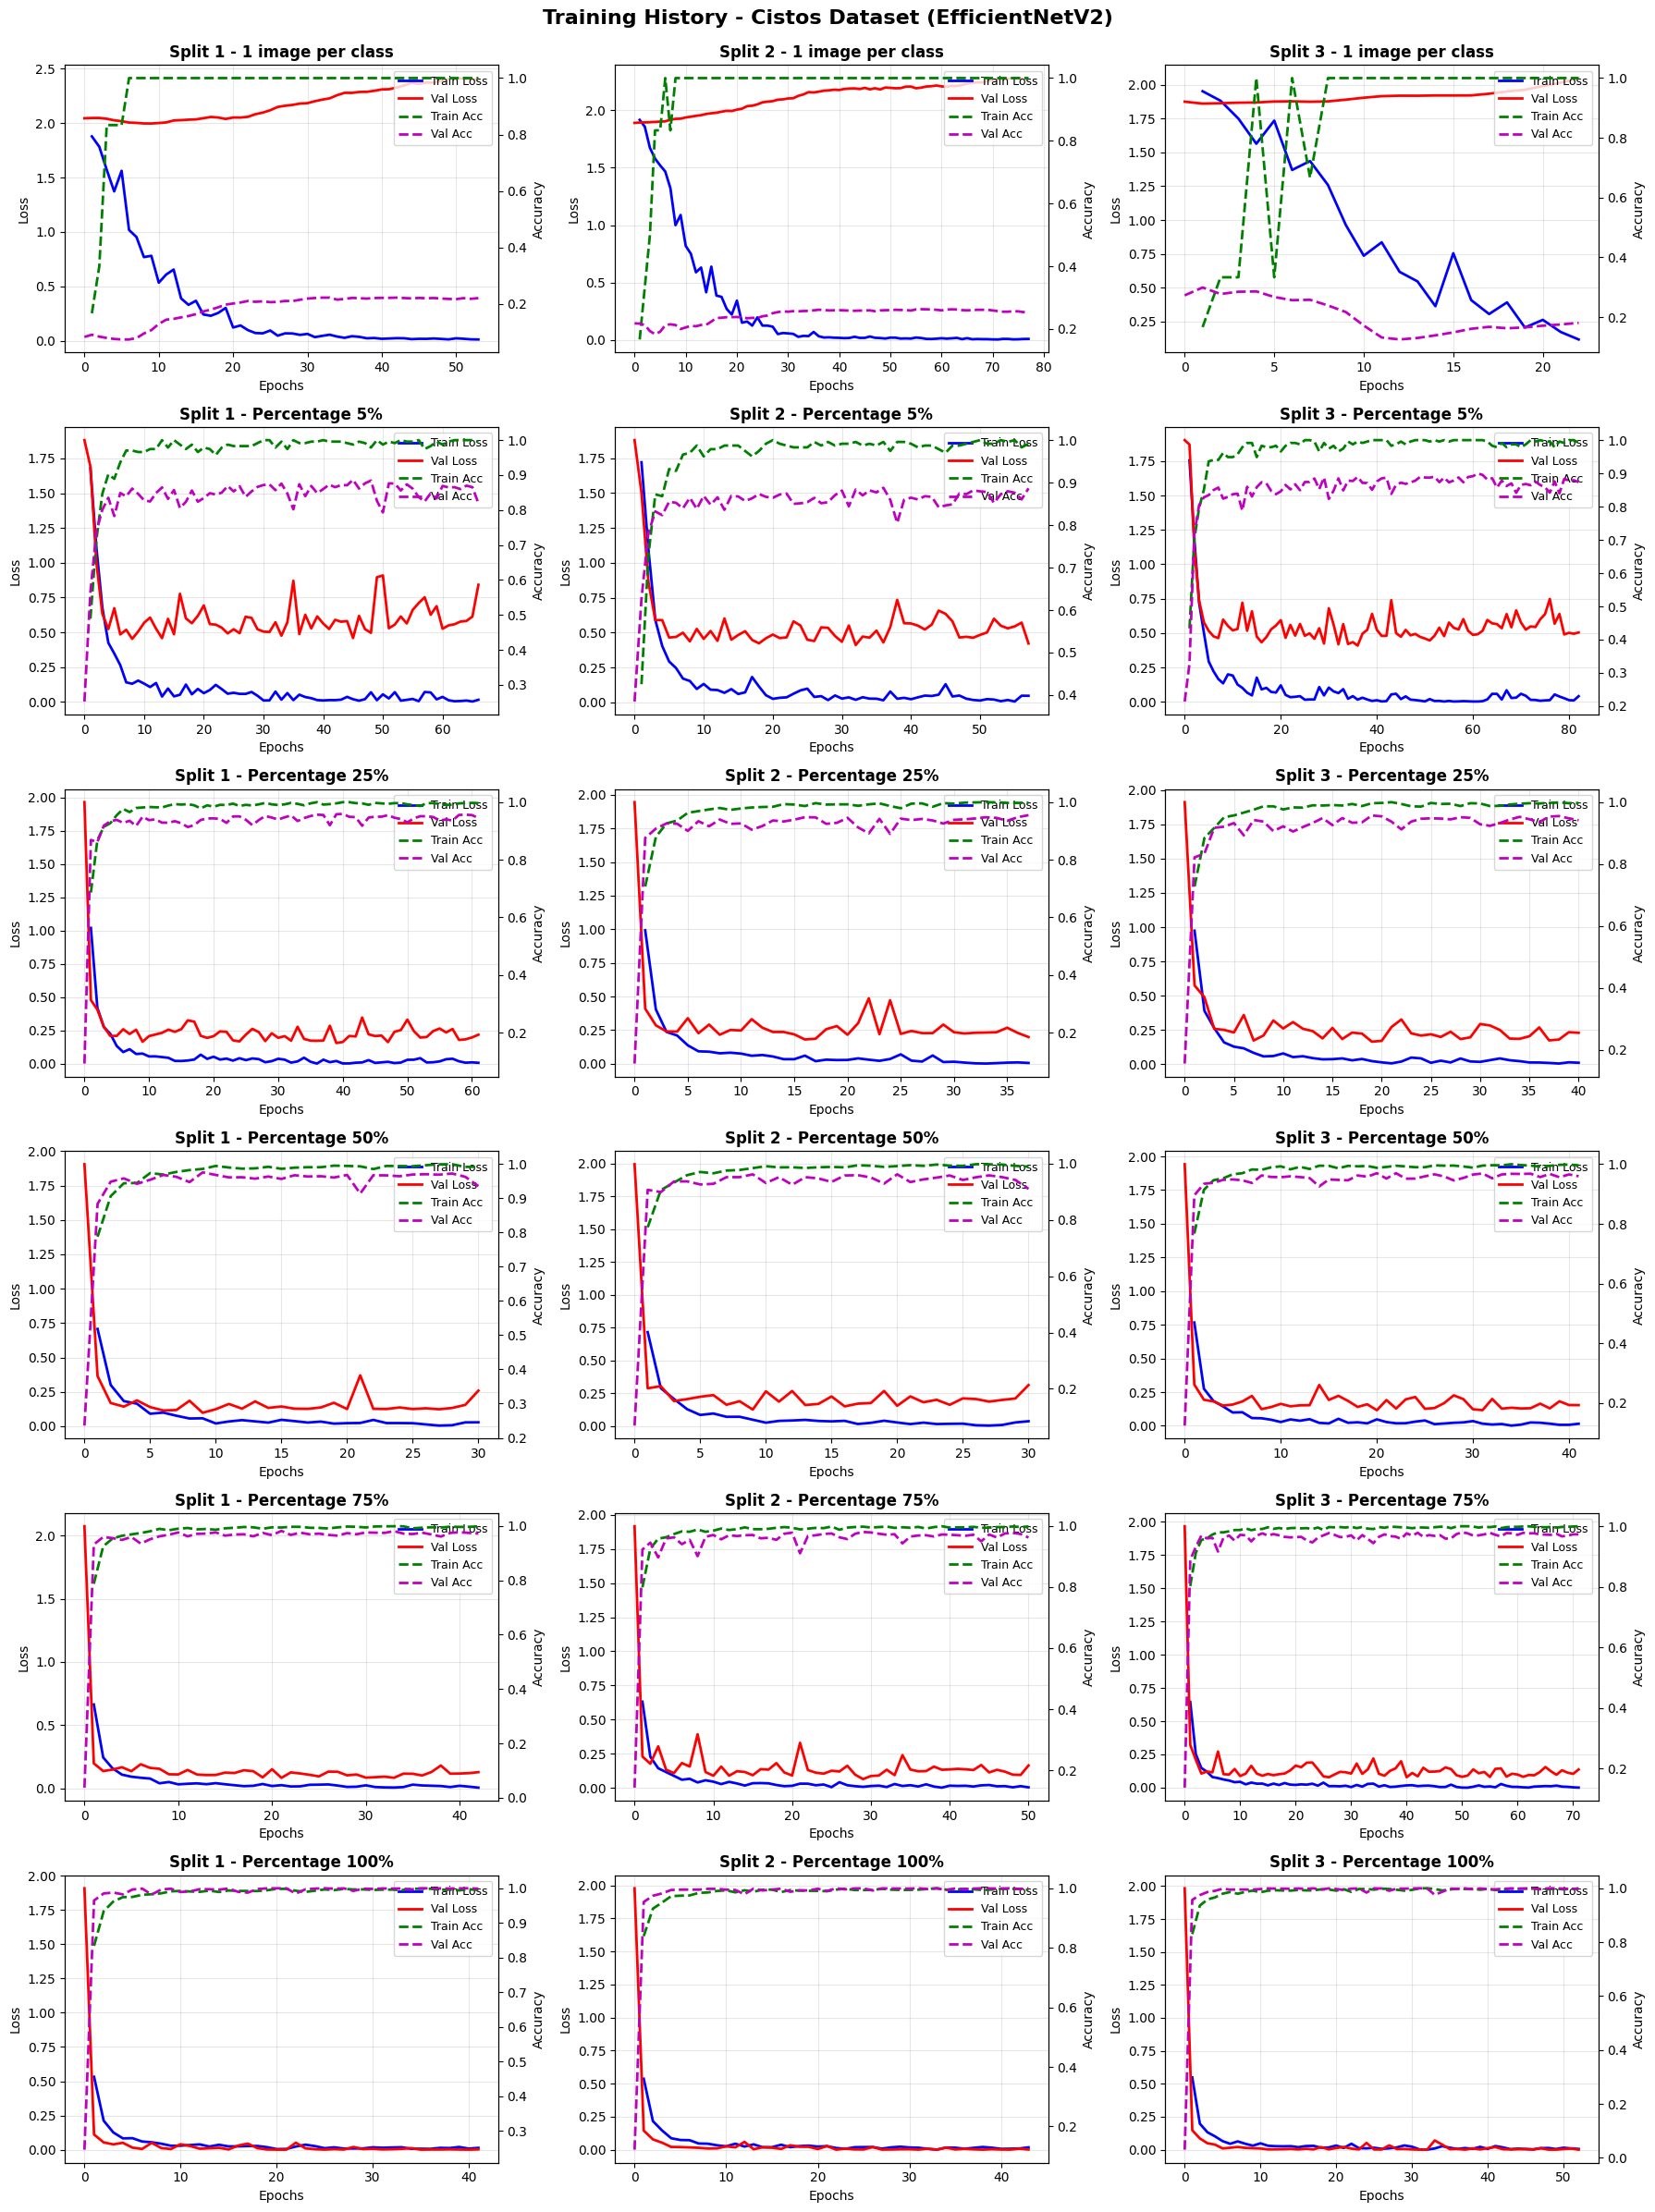

In [10]:
load = False
# load historic from json - commented out because already loaded above 
load = True
with open('efficientnetv2/cistos/efficientnetv2_historic_cistos.json', 'r') as f:
    historic_cistos = json.load(f)

# Loss and Accuracy plots for cistos dataset (EfficientNet)
fig, axes = plt.subplots(len(CONFIG_CISTO['percentage']), len(CONFIG_CISTO['split']), 
                         figsize=(18, 4 * len(CONFIG_CISTO['percentage'])))

for perc_idx, perc in enumerate(CONFIG_CISTO['percentage']):
    for split_idx, split in enumerate(CONFIG_CISTO['split']):
        ax = axes[perc_idx, split_idx]
        
        if load==True:
            history = historic_cistos[str(perc)][str(split)]
        else:
            history = historic_cistos[perc][split]
        epochs = range(1, len(history['train_loss']) + 1)
        epochs_val = range(0, len(history['val_loss']))
        
        # Plot loss
        ax_loss = ax
        ax_loss.plot(epochs, history['train_loss'], 'b-', label='Train Loss', linewidth=2)
        ax_loss.plot(epochs_val, history['val_loss'], 'r-', label='Val Loss', linewidth=2)
        ax_loss.set_xlabel('Epochs')
        ax_loss.set_ylabel('Loss', color='black')
        ax_loss.tick_params(axis='y', labelcolor='black')
        
        # Create secondary y-axis for accuracy
        ax_acc = ax.twinx()
        ax_acc.plot(epochs, history['train_acc'], 'g--', label='Train Acc', linewidth=2)
        ax_acc.plot(epochs_val, history['val_acc'], 'm--', label='Val Acc', linewidth=2)
        ax_acc.set_ylabel('Accuracy', color='black')
        ax_acc.tick_params(axis='y', labelcolor='black')
        
        # Title
        if perc == 1:
            ax.set_title(f'Split {split} - 1 image per class', fontsize=12, fontweight='bold')
        else: 
            ax.set_title(f'Split {split} - Percentage {perc}%', fontsize=12, fontweight='bold')
        
        # Grid
        ax.grid(True, alpha=0.3)
        
        # Combine legends
        lines1, labels1 = ax_loss.get_legend_handles_labels()
        lines2, labels2 = ax_acc.get_legend_handles_labels()
        ax.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=9)

plt.suptitle('Training History - Cistos Dataset (EfficientNetV2)', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('efficientnetv2/cistos/training_history_cistos_grid_efficientnetv2.png', dpi=300, bbox_inches='tight')
plt.show()

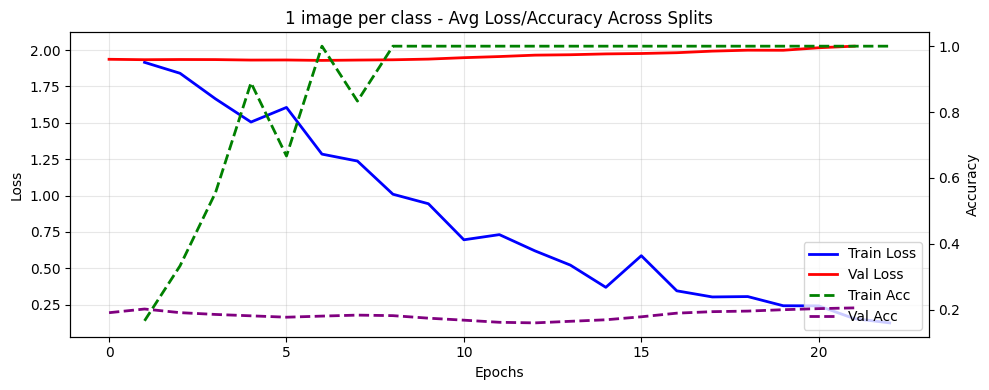

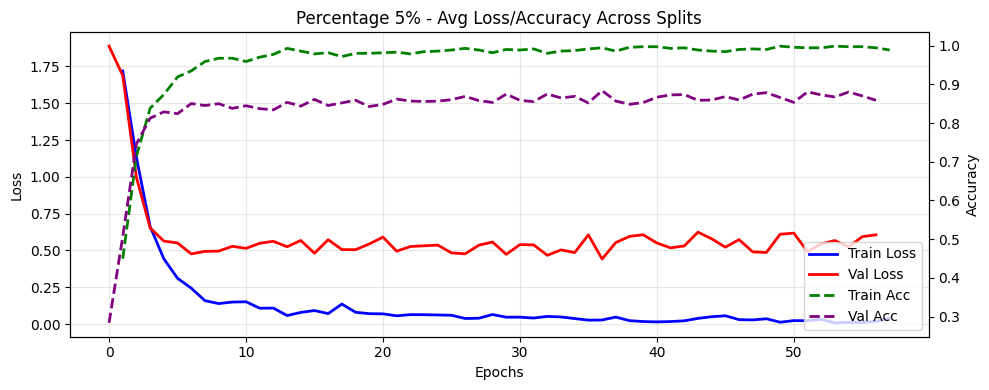

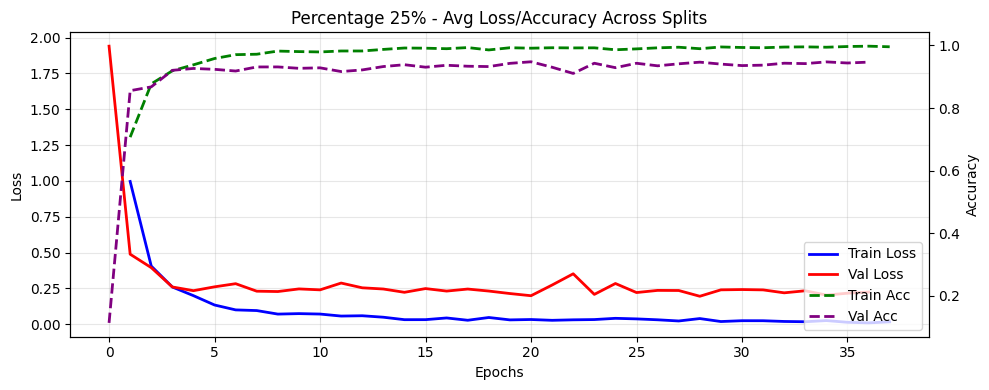

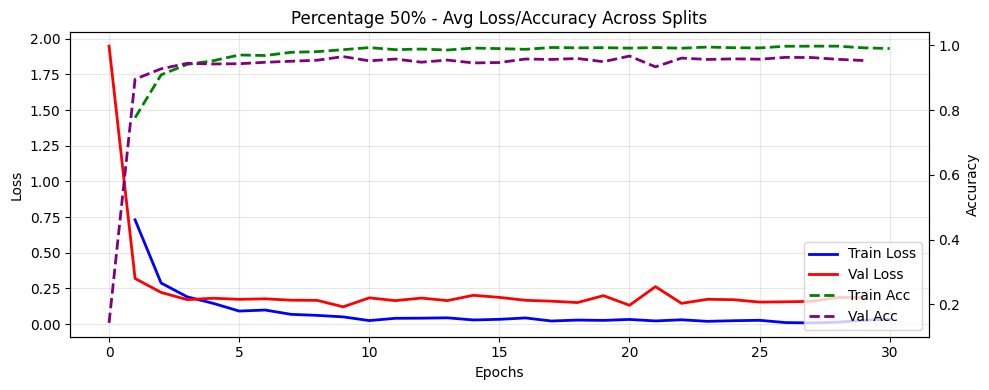

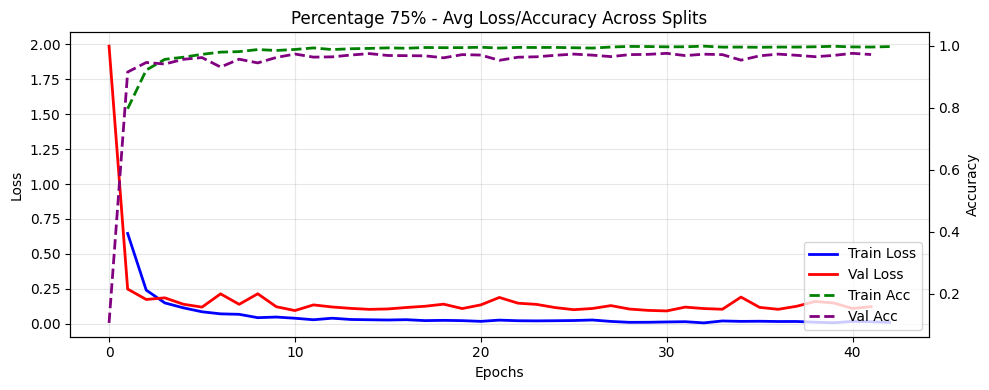

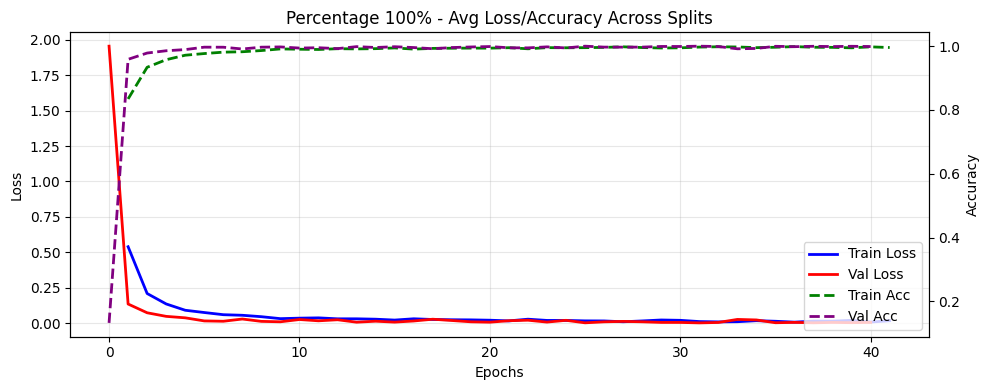

In [11]:
load = False
# load historic from json - commented out because already loaded above
load = True
with open('efficientnetv2/cistos/efficientnetv2_historic_cistos.json', 'r') as f:
    historic_cistos = json.load(f)

# Loss and Accuracy aggregated plots for eggs dataset (EfficientNet)
agg_rows = []
for perc in CONFIG_CISTO['percentage']:
    all_train_loss = []
    all_val_loss = []
    all_train_acc = []
    all_val_acc = []
    
    # Collect histories for all splits
    for split in CONFIG_CISTO['split']:
        if load==True:
            history = historic_cistos[str(perc)][str(split)]
        else:
            history = historic_cistos[perc][split]
        all_train_loss.append(history['train_loss'])
        all_val_loss.append(history['val_loss'])
        all_train_acc.append(history['train_acc'])
        all_val_acc.append(history['val_acc'])
    
    # Find the minimum number of epochs across splits (due to early stopping)
    min_len = min(len(x) for x in all_train_loss)
    
    # Truncate all histories to the minimum length
    all_train_loss_trunc = [x[:min_len] for x in all_train_loss]
    all_val_loss_trunc = [x[:min_len] for x in all_val_loss]
    all_train_acc_trunc = [x[:min_len] for x in all_train_acc]
    all_val_acc_trunc = [x[:min_len] for x in all_val_acc]
    
    # Calculate averages
    avg_train_loss = np.mean(all_train_loss_trunc, axis=0)
    avg_val_loss = np.mean(all_val_loss_trunc, axis=0)
    avg_train_acc = np.mean(all_train_acc_trunc, axis=0)
    avg_val_acc = np.mean(all_val_acc_trunc, axis=0)
    
    # Store aggregated results
    agg_rows.append({
        'percentage': perc,
        'avg_train_loss': avg_train_loss,
        'avg_val_loss': avg_val_loss,
        'avg_train_acc': avg_train_acc,
        'avg_val_acc': avg_val_acc,
    })

# Plot aggregated loss and accuracy per percentage
for agg in agg_rows:
    epochs = range(1, len(agg['avg_train_loss']) + 1)
    epochs_val = range(0, len(agg['avg_val_loss']))
    
    fig, ax1 = plt.subplots(figsize=(10, 4))
    ax1.plot(epochs, agg['avg_train_loss'], label='Train Loss', color='blue', linewidth=2)
    ax1.plot(epochs_val, agg['avg_val_loss'], label='Val Loss', color='red', linewidth=2)
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.grid(True, alpha=0.3)

    ax2 = ax1.twinx()
    ax2.plot(epochs, agg['avg_train_acc'], label='Train Acc', color='green', linestyle='--', linewidth=2)
    ax2.plot(epochs_val, agg['avg_val_acc'], label='Val Acc', color='purple', linestyle='--', linewidth=2)
    ax2.set_ylabel('Accuracy')

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower right')

    if agg['percentage'] == 1:
        ax1.set_title(f'1 image per class - Avg Loss/Accuracy Across Splits')
    else:   
        ax1.set_title(f'Percentage {agg["percentage"]}% - Avg Loss/Accuracy Across Splits')
    plt.savefig(f'efficientnetv2/cistos/aggregated_loss_accuracy_cistos_perc{agg["percentage"]}.png', dpi=300, bbox_inches='tight')
    
    plt.tight_layout()
    plt.show()


In [12]:
# Evaluate on test set and save metrics
results_cistos = {}

for perc in CONFIG_CISTO['percentage']:
    results_cistos[perc] = {}
    for split in CONFIG_CISTO['split']:
        
        # Create a model instance that matches the checkpoint (uses CONFIG_EGG)
        efficientnet_model_eval, _, _, _ = create_efficientnetv2_model(None, CONFIG_CISTO)
        # Load the checkpoint into that model (ensure loading on correct device)
        efficientnet_model_eval.load_state_dict(torch.load(
            f'efficientnetv2/cistos/best_models_cistos/efficientnetv2_best_split{split}_perc{perc}.pth',
            map_location=CONFIG_CISTO['device']
        ))
        efficientnet_model_eval.to(CONFIG_CISTO['device'])
        efficientnet_model_eval.eval()
        
        all_preds = []
        all_labels = []
        
        with torch.no_grad():
            for inputs, labels in tqdm(dataloaders_cisto[split][perc]['test'], desc=f'Testing Split {split} Perc {perc}%', leave=False):
                inputs, labels = inputs.to(CONFIG_CISTO['device']), labels.to(CONFIG_CISTO['device'])
                outputs = efficientnet_model_eval(inputs)
                _, preds = torch.max(outputs, 1)
                
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
        
        # Calculate metrics
        cm = confusion_matrix(all_labels, all_preds)
        kappa = cohen_kappa_score(all_labels, all_preds)
        report_dic = classification_report(all_labels, all_preds, zero_division=0, output_dict=True)
        report_str = classification_report(all_labels, all_preds, zero_division=0) 
        
        # Store results
        results_cistos[perc][split] = {
            'confusion_matrix': cm.tolist(),
            'kappa': float(kappa),
            'classification_report_dict': report_dic,
            'classification_report_str': report_str
        }
        
# Save results to JSON
with open('efficientnetv2/cistos/efficientnetv2_test_results_cistos.json', 'w') as f:
    json.dump(results_cistos, f)

In [13]:
load = False
# Load results from JSON - commented out because already loaded above
load = True
with open('efficientnetv2/cistos/efficientnetv2_test_results_cistos.json', 'r') as f:
    results_cistos = json.load(f)

# JSON keys become strings after loading. Convert keys back to ints when possible
def _convert_keys_to_int(obj):
    if isinstance(obj, dict):
        new = {}
        for k, v in obj.items():
            try:
                new_k = int(k)
            except Exception:
                new_k = k
            new[new_k] = _convert_keys_to_int(v)
        return new
    return obj

results_cistos = _convert_keys_to_int(results_cistos)

# delete any existing aggregated report file
if os.path.exists('efficientnetv2/cistos/efficientnetv2_aggregated_classification_report_cistos.txt'):
    os.remove('efficientnetv2/cistos/efficientnetv2_aggregated_classification_report_cistos.txt')
print("=== Aggregated Reports (Mean ± Standard Deviation) ===")

for perc in CONFIG_CISTO['percentage']:
    # print(f"\n>> Percentage: {perc}%")
    df_result = generate_mean_std_report(results_cistos, perc, CONFIG_CISTO['split'])
    
    if df_result is not None:
        # Cosmetic adjustment to match sklearn print
        # Replace NaN with empty string to clean the accuracy line
        # print(df_result.fillna('').to_markdown()) 
        
        # Optional: Save all percentages in a single txt        
        with open('efficientnetv2/cistos/efficientnetv2_aggregated_classification_report_cistos.txt', 'a') as f:
            f.write(f"\n>> Percentage: {perc}%\n")
            f.write(df_result.fillna('').to_string())
            f.write("\n\n")

=== Aggregated Reports (Mean ± Standard Deviation) ===


### Larvae

In [8]:
# Configuration for Larvae Dataset
CONFIG_LARVAE = {
    'dataset_name': 'larvae',
    'split': [1,2,3],
    'percentage': [1, 5, 25, 50, 75, 100],
    'num_classes': 2,
    'batch_size': 16,
    'num_workers': 4,
    'image_size': 200,
    'lr': 1e-4,
    'num_epochs': 100,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu'
}

# Create dataloaders
dataloaders_larvae = {}

transforms_larvae = transforms.Compose([
    transforms.Resize((CONFIG_LARVAE['image_size'], CONFIG_LARVAE['image_size'])),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

for split in CONFIG_LARVAE['split']:
    dataloaders_larvae[split] = {}
    for perc in CONFIG_LARVAE['percentage']:
        data_module = DataModuleParasite(
            dataset_name=CONFIG_LARVAE['dataset_name'],
            split=split,
            percentage=perc,
            batch_size=CONFIG_LARVAE['batch_size'],
            num_workers=CONFIG_LARVAE['num_workers'],
            transform=transforms_larvae
        )
        data_module.setup()
        dataloaders_larvae[split][perc] = {
            'train': data_module.train_dataloader(),
            'val': data_module.val_dataloader(),
            'test': data_module.test_dataloader()
        }

model_pretrained, _, _, _ = create_efficientnetv2_model(description_path="efficientnetv2/larvae/efficientnetv2_model_params_larvae.txt", config=CONFIG_LARVAE)

In [9]:
n_flops, n_params = count_flops(model_pretrained, input_size=(1, 3, CONFIG_LARVAE['image_size'], CONFIG_LARVAE['image_size']))
print(f"Model: efficientnetv2 - Dataset: {CONFIG_LARVAE['dataset_name']}")
# mostra o valor total
print(f"FLOPs: {n_flops} FLOPs")
print(f"Parameters: {n_params} ")

Model: efficientnetv2 - Dataset: larvae
FLOPs: 2480064832.0 FLOPs
Parameters: 20180050.0 


In [15]:
historic_larvae = {}
patience = 20 

for perc in CONFIG_LARVAE['percentage']:
    historic_larvae[perc] = {}
    for split in CONFIG_LARVAE['split']:

        model_pretrained, criterion, optimizer, scheduler = create_efficientnetv2_model(None, CONFIG_LARVAE)
        epochs_no_improve = 0
        
        best_val_acc = 0.0
        historic_larvae[perc][split] = {
            'train_loss': [],
            'train_acc': [],
            'val_loss': [],
            'val_acc': []
        }
        
        for epoch in tqdm(range(CONFIG_LARVAE['num_epochs']), desc=f"Split {split} - Percentage {perc}%", leave=False):
            
            val_loss, val_acc = evaluate(model_pretrained, dataloaders_larvae[split][perc]['val'], criterion, CONFIG_LARVAE['device'])

            train_loss, train_acc = train(model_pretrained, dataloaders_larvae[split][perc]['train'], criterion, optimizer, CONFIG_LARVAE['device'])
            historic_larvae[perc][split]['train_loss'].append(train_loss)
            historic_larvae[perc][split]['train_acc'].append(train_acc)
            historic_larvae[perc][split]['val_loss'].append(val_loss)
            historic_larvae[perc][split]['val_acc'].append(val_acc)
            
            # Early Stopping
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                epochs_no_improve = 0
                os.makedirs('efficientnetv2/larvae/best_models_larvae', exist_ok=True)
                torch.save(model_pretrained.state_dict(), f'efficientnetv2/larvae/best_models_larvae/efficientnetv2_best_split{split}_perc{perc}.pth')
            else:
                epochs_no_improve += 1
                if epochs_no_improve >= patience:
                    print(f'Early stopping at epoch {epoch+1} for split {split} and percentage {perc}%')
                    break

        val_loss, val_acc = evaluate(model_pretrained, dataloaders_larvae[split][perc]['val'], criterion, CONFIG_LARVAE['device'])

        historic_larvae[perc][split]['val_loss'].append(val_loss)
        historic_larvae[perc][split]['val_acc'].append(val_acc)
            
        scheduler.step()
        
# Save training history
with open('efficientnetv2/larvae/efficientnetv2_historic_larvae.json', 'w') as f:
    json.dump(historic_larvae, f)

Early stopping at epoch 21 for split 1 and percentage 1%


Early stopping at epoch 38 for split 2 and percentage 1%


Early stopping at epoch 62 for split 3 and percentage 1%


Early stopping at epoch 38 for split 1 and percentage 5%


Early stopping at epoch 36 for split 2 and percentage 5%


...

Early stopping at epoch 46 for split 2 and percentage 75%


Early stopping at epoch 53 for split 3 and percentage 75%


Early stopping at epoch 25 for split 1 and percentage 100%


Early stopping at epoch 26 for split 2 and percentage 100%


Early stopping at epoch 27 for split 3 and percentage 100%


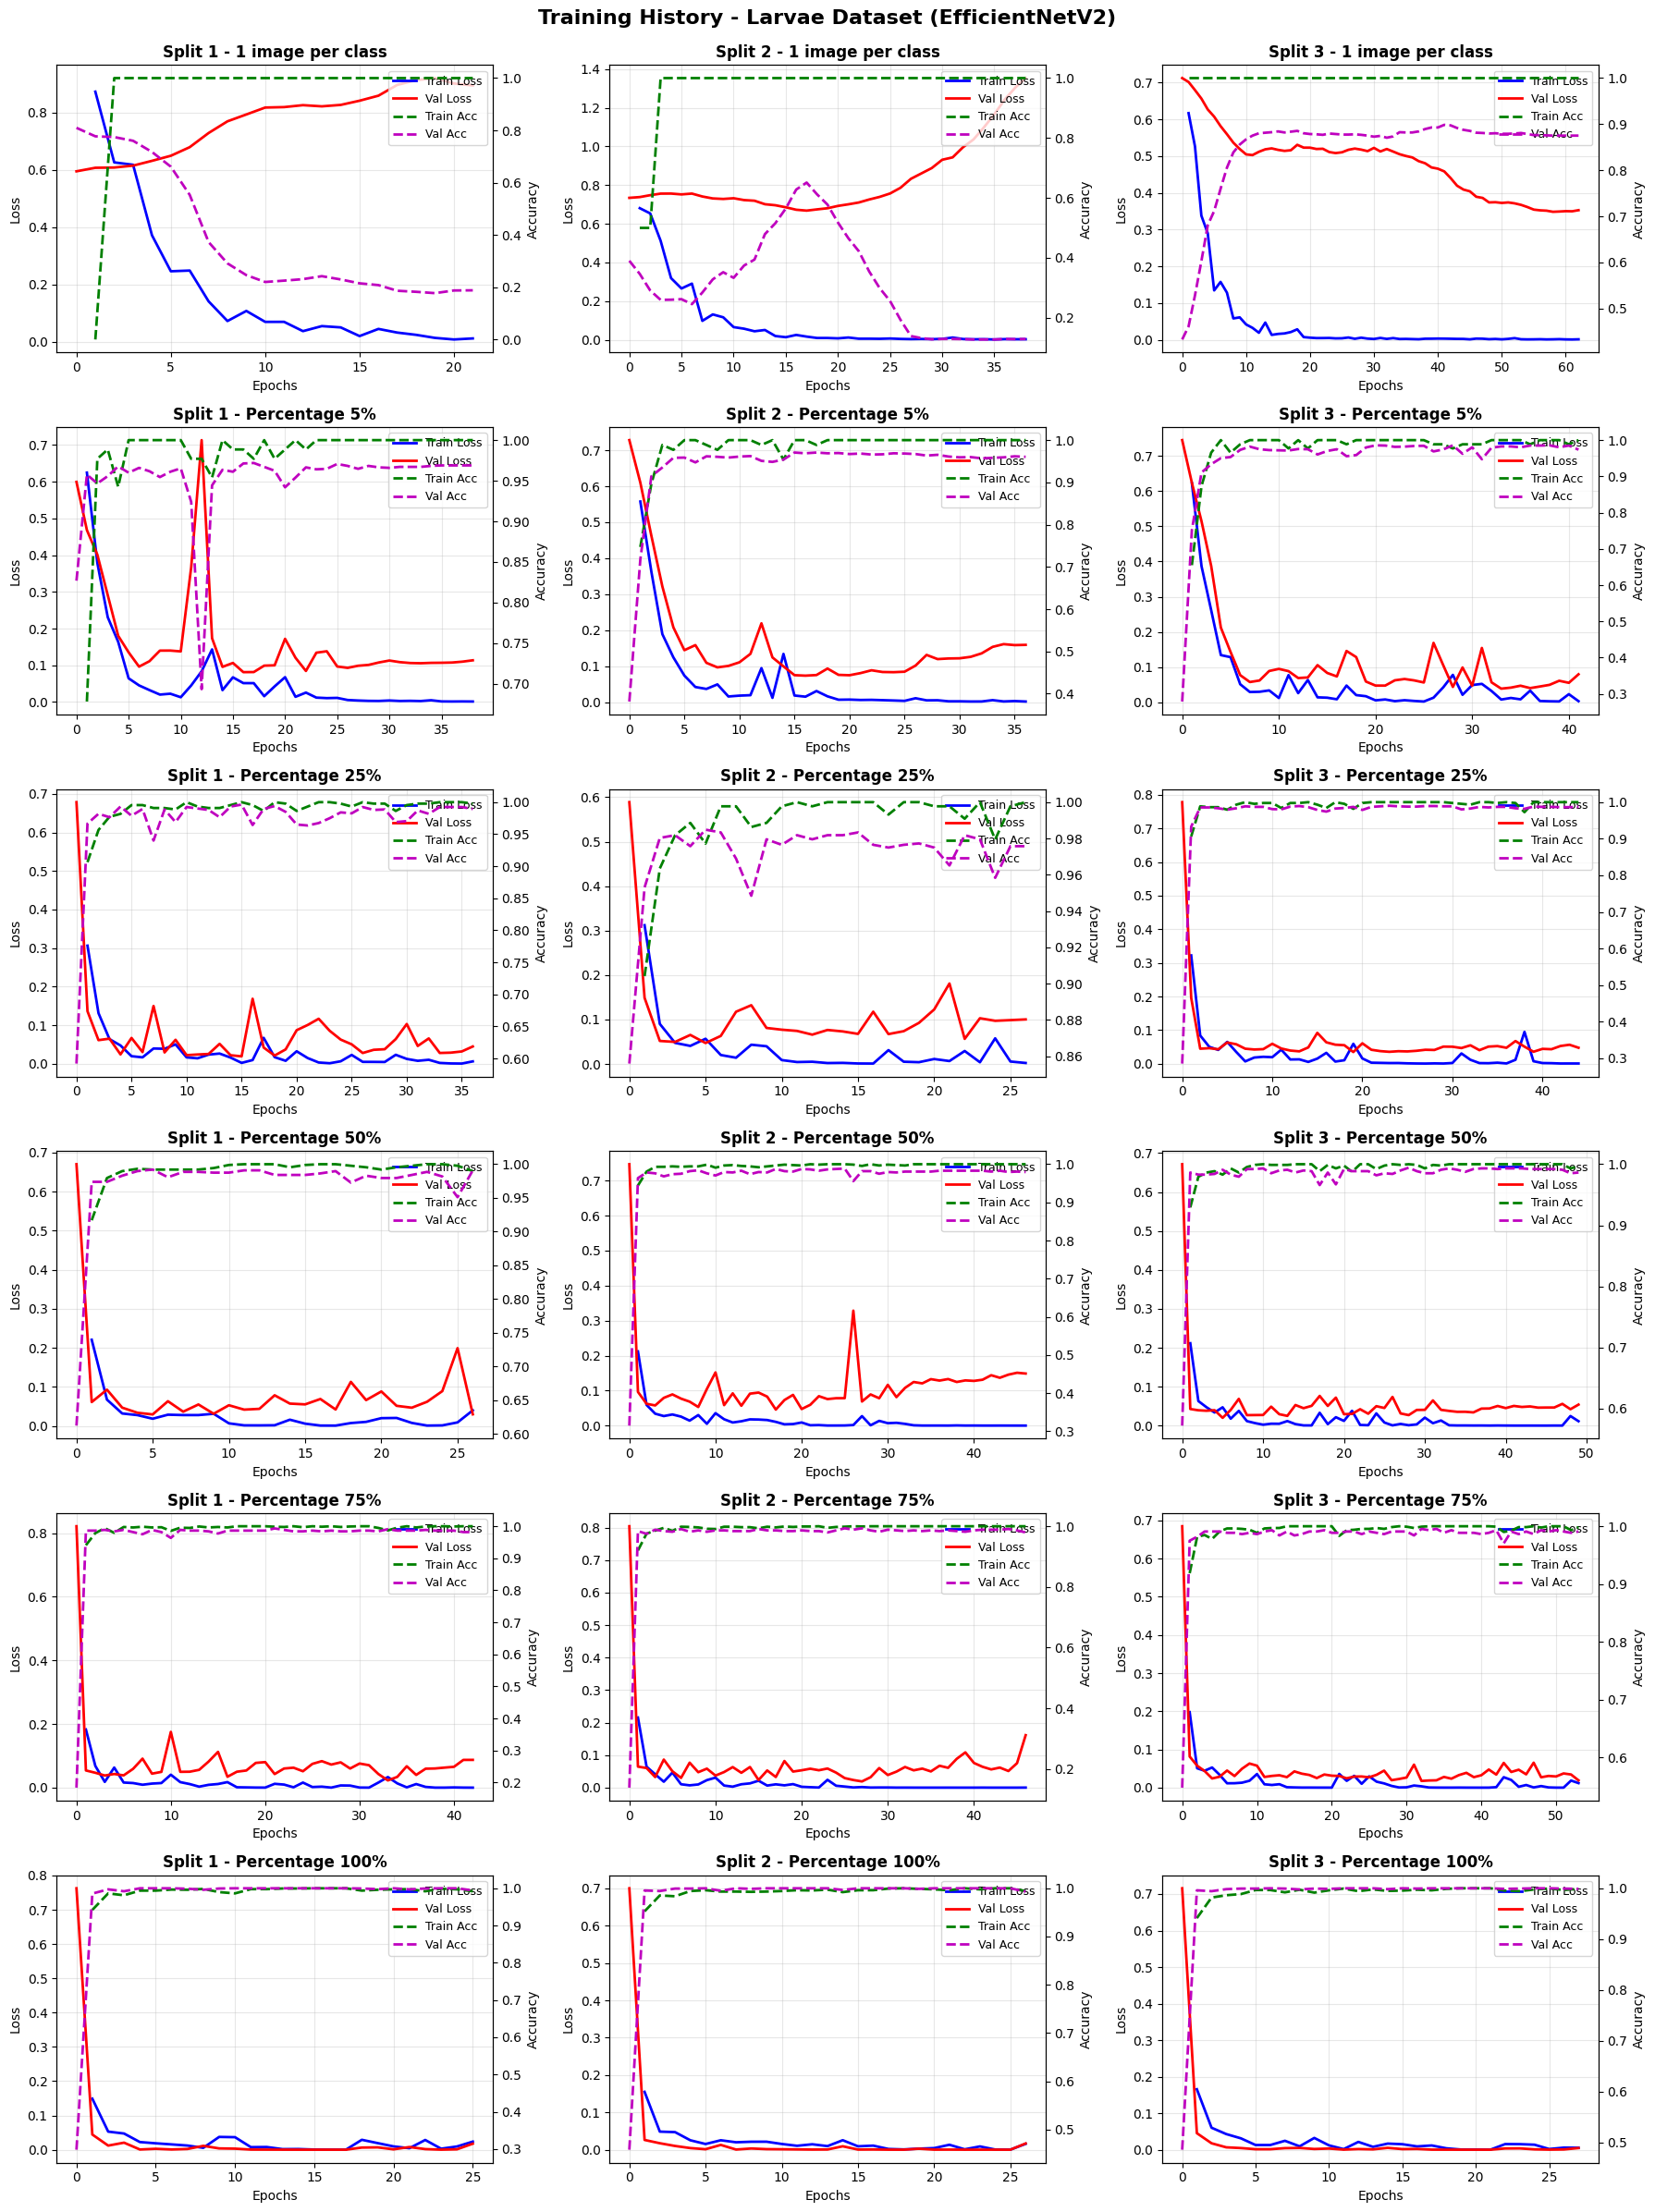

In [15]:
load = False
# load historic from json - commented out because already loaded above 
load = True
with open('efficientnetv2/larvae/efficientnetv2_historic_larvae.json', 'r') as f:
    historic_larvae = json.load(f)

# Loss and Accuracy plots for larvae dataset (EfficientNet)
fig, axes = plt.subplots(len(CONFIG_LARVAE['percentage']), len(CONFIG_LARVAE['split']), 
                         figsize=(18, 4 * len(CONFIG_LARVAE['percentage'])))

for perc_idx, perc in enumerate(CONFIG_LARVAE['percentage']):
    for split_idx, split in enumerate(CONFIG_LARVAE['split']):
        ax = axes[perc_idx, split_idx]
        
        if load==True:
            history = historic_larvae[str(perc)][str(split)]
        else:
            history = historic_larvae[perc][split]
        epochs = range(1, len(history['train_loss']) + 1)
        epochs_val = range(0, len(history['val_loss']))
        
        # Plot loss
        ax_loss = ax
        ax_loss.plot(epochs, history['train_loss'], 'b-', label='Train Loss', linewidth=2)
        ax_loss.plot(epochs_val, history['val_loss'], 'r-', label='Val Loss', linewidth=2)
        ax_loss.set_xlabel('Epochs')
        ax_loss.set_ylabel('Loss', color='black')
        ax_loss.tick_params(axis='y', labelcolor='black')
        
        # Create secondary y-axis for accuracy
        ax_acc = ax.twinx()
        ax_acc.plot(epochs, history['train_acc'], 'g--', label='Train Acc', linewidth=2)
        ax_acc.plot(epochs_val, history['val_acc'], 'm--', label='Val Acc', linewidth=2)
        ax_acc.set_ylabel('Accuracy', color='black')
        ax_acc.tick_params(axis='y', labelcolor='black')
        
        # Title
        if perc == 1:
            ax.set_title(f'Split {split} - 1 image per class', fontsize=12, fontweight='bold')
        else: 
            ax.set_title(f'Split {split} - Percentage {perc}%', fontsize=12, fontweight='bold')
        
        # Grid
        ax.grid(True, alpha=0.3)
        
        # Combine legends
        lines1, labels1 = ax_loss.get_legend_handles_labels()
        lines2, labels2 = ax_acc.get_legend_handles_labels()
        ax.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=9)

plt.suptitle('Training History - Larvae Dataset (EfficientNetV2)', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('efficientnetv2/larvae/training_history_larvae_grid_efficientnetv2.png', dpi=300, bbox_inches='tight')
plt.show()

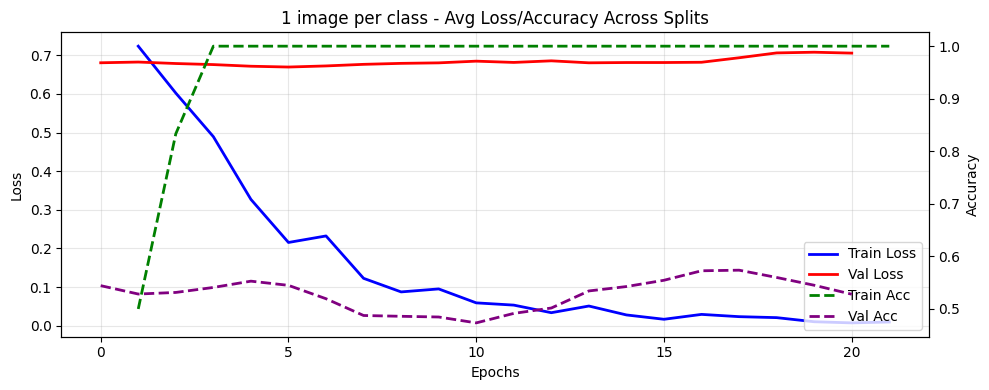

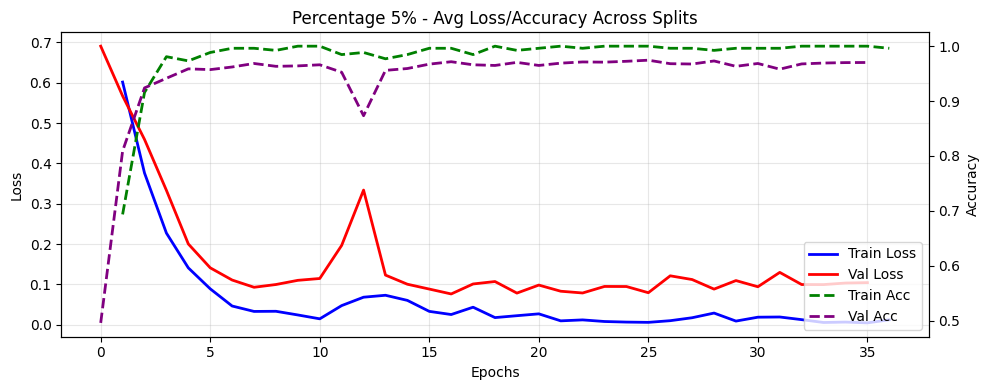

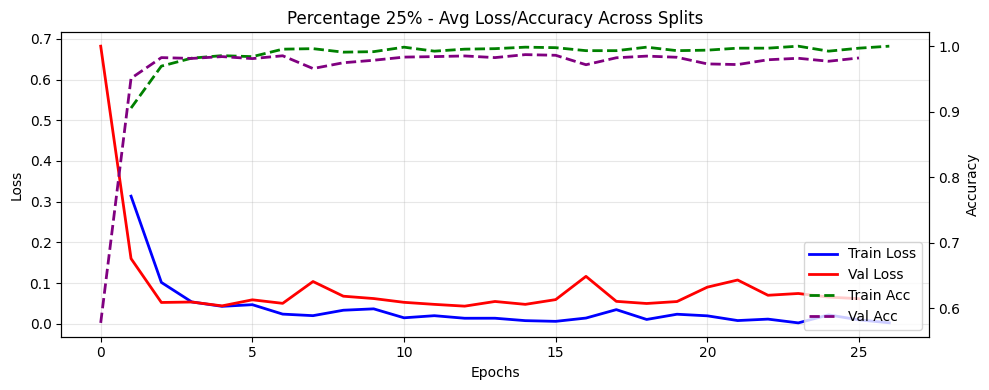

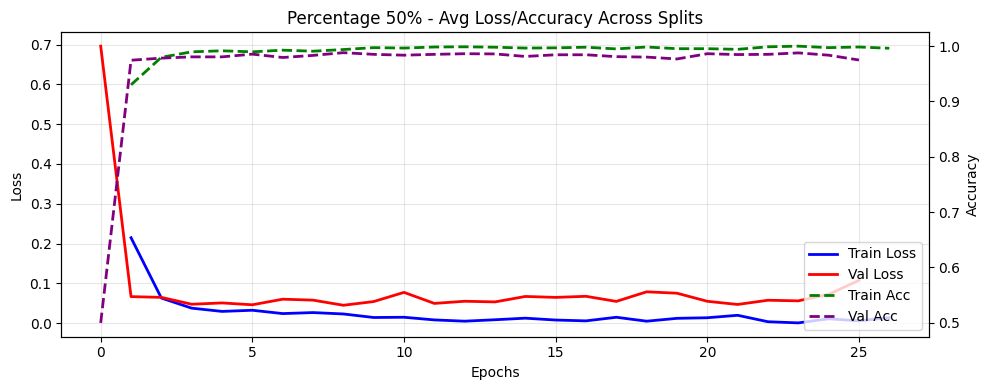

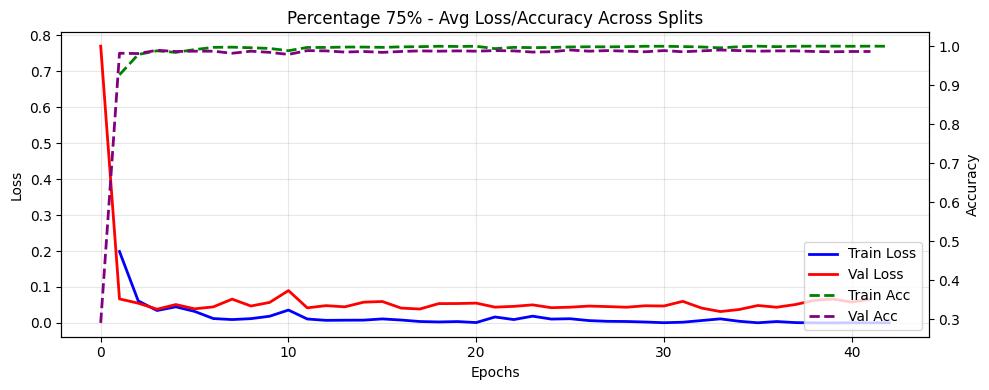

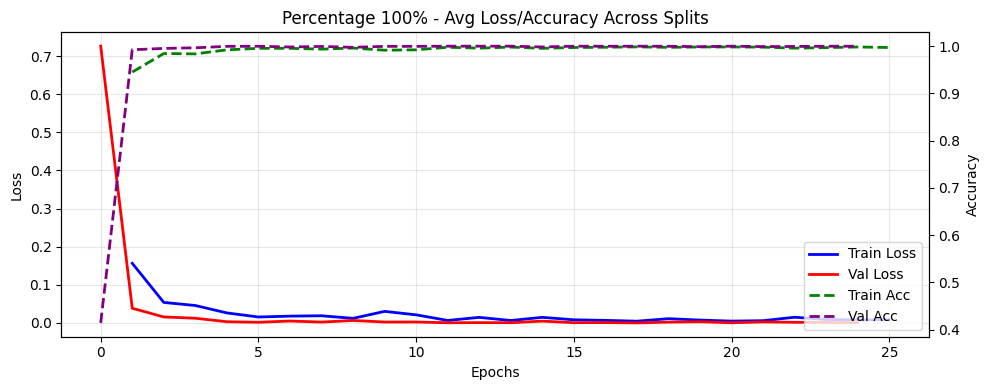

In [16]:
load = False
# load historic from json - commented out because already loaded above
load = True
with open('efficientnetv2/larvae/efficientnetv2_historic_larvae.json', 'r') as f:
    historic_larvae = json.load(f)

# Loss and Accuracy aggregated plots for larvae dataset (EfficientNet)
agg_rows = []
for perc in CONFIG_LARVAE['percentage']:
    all_train_loss = []
    all_val_loss = []
    all_train_acc = []
    all_val_acc = []
    
    # Collect histories for all splits
    for split in CONFIG_LARVAE['split']:
        if load==True:
            history = historic_larvae[str(perc)][str(split)]
        else:
            history = historic_larvae[perc][split]
        all_train_loss.append(history['train_loss'])
        all_val_loss.append(history['val_loss'])
        all_train_acc.append(history['train_acc'])
        all_val_acc.append(history['val_acc'])
    
    # Find the minimum number of epochs across splits (due to early stopping)
    min_len = min(len(x) for x in all_train_loss)
    
    # Truncate all histories to the minimum length
    all_train_loss_trunc = [x[:min_len] for x in all_train_loss]
    all_val_loss_trunc = [x[:min_len] for x in all_val_loss]
    all_train_acc_trunc = [x[:min_len] for x in all_train_acc]
    all_val_acc_trunc = [x[:min_len] for x in all_val_acc]
    
    # Calculate averages
    avg_train_loss = np.mean(all_train_loss_trunc, axis=0)
    avg_val_loss = np.mean(all_val_loss_trunc, axis=0)
    avg_train_acc = np.mean(all_train_acc_trunc, axis=0)
    avg_val_acc = np.mean(all_val_acc_trunc, axis=0)
    
    # Store aggregated results
    agg_rows.append({
        'percentage': perc,
        'avg_train_loss': avg_train_loss,
        'avg_val_loss': avg_val_loss,
        'avg_train_acc': avg_train_acc,
        'avg_val_acc': avg_val_acc,
    })

# Plot aggregated loss and accuracy per percentage
for agg in agg_rows:
    epochs = range(1, len(agg['avg_train_loss']) + 1)
    epochs_val = range(0, len(agg['avg_val_loss']))
    
    fig, ax1 = plt.subplots(figsize=(10, 4))
    ax1.plot(epochs, agg['avg_train_loss'], label='Train Loss', color='blue', linewidth=2)
    ax1.plot(epochs_val, agg['avg_val_loss'], label='Val Loss', color='red', linewidth=2)
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.grid(True, alpha=0.3)

    ax2 = ax1.twinx()
    ax2.plot(epochs, agg['avg_train_acc'], label='Train Acc', color='green', linestyle='--', linewidth=2)
    ax2.plot(epochs_val, agg['avg_val_acc'], label='Val Acc', color='purple', linestyle='--', linewidth=2)
    ax2.set_ylabel('Accuracy')

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower right')

    if agg['percentage'] == 1:
        ax1.set_title(f'1 image per class - Avg Loss/Accuracy Across Splits')
    else:   
        ax1.set_title(f'Percentage {agg["percentage"]}% - Avg Loss/Accuracy Across Splits')
    plt.savefig(f'efficientnetv2/larvae/aggregated_loss_accuracy_larvae_perc{agg["percentage"]}.png', dpi=300, bbox_inches='tight')
    
    plt.tight_layout()
    plt.show()


In [17]:
# Evaluate on test set and save metrics
results_larvae = {}

for perc in CONFIG_LARVAE['percentage']:
    results_larvae[perc] = {}
    for split in CONFIG_LARVAE['split']:
        
        # Create a model instance that matches the checkpoint (uses CONFIG_EGG)
        efficientnet_model_eval, _, _, _ = create_efficientnetv2_model(None, CONFIG_LARVAE)
        # Load the checkpoint into that model (ensure loading on correct device)
        efficientnet_model_eval.load_state_dict(torch.load(
            f'efficientnetv2/larvae/best_models_larvae/efficientnetv2_best_split{split}_perc{perc}.pth',
            map_location=CONFIG_LARVAE['device']
        ))
        efficientnet_model_eval.to(CONFIG_LARVAE['device'])
        efficientnet_model_eval.eval()
        
        all_preds = []
        all_labels = []
        
        with torch.no_grad():
            for inputs, labels in tqdm(dataloaders_larvae[split][perc]['test'], desc=f'Testing Split {split} Perc {perc}%', leave=False):
                inputs, labels = inputs.to(CONFIG_LARVAE['device']), labels.to(CONFIG_LARVAE['device'])
                outputs = efficientnet_model_eval(inputs)
                _, preds = torch.max(outputs, 1)
                
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
        
        # Calculate metrics
        cm = confusion_matrix(all_labels, all_preds)
        kappa = cohen_kappa_score(all_labels, all_preds)
        report_dic = classification_report(all_labels, all_preds, zero_division=0, output_dict=True)
        report_str = classification_report(all_labels, all_preds, zero_division=0) 
        
        # Store results
        results_larvae[perc][split] = {
            'confusion_matrix': cm.tolist(),
            'kappa': float(kappa),
            'classification_report_dict': report_dic,
            'classification_report_str': report_str
        }
        
# Save results to JSON
with open('efficientnetv2/larvae/efficientnetv2_test_results_larvae.json', 'w') as f:
    json.dump(results_larvae, f)

In [19]:
load = False
# Load results from JSON - commented out because already loaded above
load = True
with open('efficientnetv2/larvae/efficientnetv2_test_results_larvae.json', 'r') as f:
    results_larvae = json.load(f)

# JSON keys become strings after loading. Convert keys back to ints when possible
def _convert_keys_to_int(obj):
    if isinstance(obj, dict):
        new = {}
        for k, v in obj.items():
            try:
                new_k = int(k)
            except Exception:
                new_k = k
            new[new_k] = _convert_keys_to_int(v)
        return new
    return obj

results_larvae = _convert_keys_to_int(results_larvae)

# delete any existing aggregated report file
if os.path.exists('efficientnetv2/larvae/efficientnetv2_aggregated_classification_report_larvae.txt'):
    os.remove('efficientnetv2/larvae/efficientnetv2_aggregated_classification_report_larvae.txt')
print("=== Aggregated Reports (Mean ± Standard Deviation) ===")

for perc in CONFIG_LARVAE['percentage']:
    # print(f"\n>> Percentage: {perc}%")
    df_result = generate_mean_std_report(results_larvae, perc, CONFIG_LARVAE['split'])
    
    if df_result is not None:
        # Cosmetic adjustment to match sklearn print
        # Replace NaN with empty string to clean the accuracy line
        # print(df_result.fillna('').to_markdown()) 
        
        # Optional: Save all percentages in a single txt        
        with open('efficientnetv2/larvae/efficientnetv2_aggregated_classification_report_larvae.txt', 'a') as f:
            f.write(f"\n>> Percentage: {perc}%\n")
            f.write(df_result.fillna('').to_string())
            f.write("\n\n")

=== Aggregated Reports (Mean ± Standard Deviation) ===
